In [2]:
#!pip install cytominer-eval
import os
import pandas as pd 
import numpy as np
import matplotlib  as mpl
import matplotlib.pyplot as plt
plt.rcParams.update({'figure.max_open_warning': 0})
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms

%matplotlib inline
import os, shutil, glob
from PIL import Image
from random import randint
# import re, math
import seaborn as sns; sns.set_style("white")
# from sklearn.manifold import TSNE
import datetime
import gc
from pathlib import Path
from cytominer_eval import evaluate
import scanpy as sc 
from sklearn.decomposition import PCA
import polars as pl
import matplotlib as mpl
# 300 dpi
mpl.rcParams['figure.dpi'] = 300
# settings to display more columns and rows
pd.set_option("max_colwidth", 200)
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

In [4]:
# features from deepprofiler aggregated by site
site_nonstd = '/home/jovyan/share/data/analyses/sofia/kinase378-vt1/DeepProfiler/project/analysis/nonnormalized_feat_site_agg_oldlabels_U20S.csv'
site_nonstd_df = pd.read_csv(f'{site_nonstd}', sep=';')


In [7]:
site_nonstd_df

,Plate,Well,Site,Metadata_cmpdID,Metadata_cmpdConc,Metadata_cmpdName,Metadata_cmpdNameConc,Metadata_cmpdIDConc,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,...,642,643,644,645,646,647,648,649,650,651,652,653,654,655,656,657,658,659,660,661,662,663,664,665,666,667,668,669,670,671,layout_id,well,batch_id,solvent,stock_conc,cmpd_vol,well_vol,pert_type,cmpd_conc,compound_id,smiles,ImageID,plateWell,old_family_label,cmpd_name,Metadata_Well,Metadata_Site,Total,ReplicateGroup,Replicate
0,P015230,B02,1,CBK278070,1.25,TGX-221,TGX-221 1.25,CBK278070-1.25,0.477952,2.642619,3.528925,1.142625,0.686796,0.796186,2.668684,0.495026,2.582346,0.911230,1.317238,2.639926,0.848894,1.211381,0.637779,0.849576,-0.209541,0.867599,0.993669,0.592119,0.934985,0.004830,2.218256,1.407300,0.866055,-0.097866,0.774995,1.340902,0.733360,-0.043711,1.248650,0.583221,2.326995,1.364514,0.806989,2.220064,2.058211,1.478519,0.654523,1.678546,0.203963,1.459653,...,1.180265,0.876066,1.605903,0.805557,1.229011,2.334649,1.225129,1.864319,0.891764,0.300179,1.248008,1.669077,1.581325,2.616026,1.551143,1.065033,0.951463,0.508469,0.702315,0.710727,1.124462,0.846066,-0.122512,0.743219,1.437395,0.593773,2.593309,1.666566,0.875236,1.305646,kinase378-v1-plate1-L1,B02,BJ1856070,DMSO,10.0,5.0,40.0,trt,1.25,CBK278070,CC(Nc1ccccc1)c1cc(C)cn2c1nc(cc2=O)N1CCOCC1,P015230_B02_1,P015230_B02,NaN,TGX-221,B02,1,0,CBK278070_1.25,CBK278070_1.25_P015230_B02_1
1,P015230,B02,2,CBK278070,1.25,TGX-221,TGX-221 1.25,CBK278070-1.25,0.506960,2.479424,3.492654,1.194212,0.703057,0.740485,2.755557,0.524770,2.792496,0.959957,1.408348,2.675404,0.872683,1.302256,0.641205,0.850783,-0.209595,0.942079,0.826876,0.573407,0.939361,0.006557,2.178265,1.492106,0.858210,-0.125999,0.786950,1.258249,0.708491,-0.004082,1.188906,0.673116,2.229232,1.350409,0.788837,2.187638,2.008773,1.533582,0.652273,1.696187,0.247588,1.501188,...,1.065715,0.886606,1.560913,0.807933,1.254731,2.333603,1.168826,1.884134,0.968410,0.252699,1.402064,1.665803,1.635193,2.491373,1.528944,1.258957,1.002922,0.464734,0.723021,0.696505,1.066437,0.928637,-0.111156,0.765859,1.424526,0.655940,2.477604,1.666599,0.825967,1.341813,kinase378-v1-plate1-L1,B02,BJ1856070,DMSO,10.0,5.0,40.0,trt,1.25,CBK278070,CC(Nc1ccccc1)c1cc(C)cn2c1nc(cc2=O)N1CCOCC1,P015230_B02_2,P015230_B02,NaN,TGX-221,B02,2,0,CBK278070_1.25,CBK278070_1.25_P015230_B02_2
2,P015230,B02,3,CBK278070,1.25,TGX-221,TGX-221 1.25,CBK278070-1.25,0.508833,2.522154,3.484644,1.047014,0.714897,0.801812,2.762285,0.459018,3.036698,0.828503,1.353184,2.664048,0.898143,1.380655,0.654771,0.815571,-0.210650,1.003570,0.999623,0.512805,0.935718,-0.048011,2.172583,1.516067,0.879260,-0.133712,0.767998,1.374072,0.775780,-0.022165,1.126918,0.652169,2.247513,1.498348,0.808588,2.254828,2.069264,1.611757,0.788377,1.660077,0.235925,1.474073,...,1.088980,0.981479,1.548479,0.858913,1.257270,2.263505,1.230304,1.883237,1.138074,0.290772,1.345481,1.741547,1.657613,2.817251,1.596258,1.268614,1.028278,0.482822,0.653682,0.729599,1.110295,0.980579,-0.116420,0.738732,1.446138,0.566864,2.593771,1.624649,0.880932,1.454168,kinase378-v1-plate1-L1,B02,BJ1856070,DMSO,10.0,5.0,40.0,trt,1.25,CBK278070,CC(Nc1ccccc1)c1cc(C)cn2c1nc(cc2=O)N1CCOCC1,P015230_B02_3,P015230_B02,NaN,TGX-221,B02,3,0,CBK278070_1.25,CBK278070_1.25_P015230_B02_3
3,P015230,B02,4,CBK278070,1.25,TGX-221,TGX-221 1.25,CBK278070-1.25,0.496063,2.568351,3.501453,1.247848,0.716906,0.748357,2.804760,0.532880,2.570343,0.952069,1.431162,2.650271,0.925205,1.279071,0.676916,0.826671,-0.207782,0.954732,0.838999,0.540103,0.914571,-0.000475,2.153278,1.505592,0.842562,-0.138462,0.767644,1.313097,0.732185,-0.003233,1.267516,0.643921,2.323573,1.362558,0.762869,2.234633,2.009284,1.528490,0.621813,1.679906,0.301587,1.493199,...,0.996223,0.905215,1.616718,0.899211,1.259635,2.351672,1.203086,1.874821,1.069673,0.333503,1.225556,1.713800,1.644968,2.547031,1.584885,1.227541,1.014544,0.485768,0.740672,0.704746,1.096172,0.851453,

In [6]:
# Add ReplicateGroup and Replicate columns.
site_nonstd_df['ReplicateGroup'] = site_nonstd_df['compound_id'] + '_' + site_nonstd_df['cmpd_conc'].astype(str) 
site_nonstd_df['Replicate'] = site_nonstd_df['ReplicateGroup'] + '_' + site_nonstd_df['ImageID']

In [8]:
# Copy the sites DataFrame
df_nonstd = site_nonstd_df.copy()


# Assuming the first 7 and the last 14 columns are metadata
metadata_columns = list(df_nonstd.columns[:8]) + list(df_nonstd.columns[-20:])
features_columns = list(df_nonstd.columns[8:-20])

# If you need to print the lists
print("Metadata columns list:", metadata_columns)
print("Features columns list:", features_columns)

Metadata columns list: ['Plate', 'Well', 'Site', 'Metadata_cmpdID', 'Metadata_cmpdConc', 'Metadata_cmpdName', 'Metadata_cmpdNameConc', 'Metadata_cmpdIDConc', 'layout_id', 'well', 'batch_id', 'solvent', 'stock_conc', 'cmpd_vol', 'well_vol', 'pert_type', 'cmpd_conc', 'compound_id', 'smiles', 'ImageID', 'plateWell', 'old_family_label', 'cmpd_name', 'Metadata_Well', 'Metadata_Site', 'Total', 'ReplicateGroup', 'Replicate']
Features columns list: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60', '61', '62', '63', '64', '65', '66', '67', '68', '69', '70', '71', '72', '73', '74', '75', '76', '77', '78', '79', '80', '81', '82', '83', '84', '85', '86', '87', '88', '89', '90', '91', '92', '93', 

In [9]:
df_nonstd.compound_id.unique()

array(['CBK278070', 'CBK278013', 'CBK041209', 'CBK290556', 'CBK149343H',
       'CBK278042', '[tetr]', 'CBK288259', 'CBK290660', 'CBK277966',
       'CBK290567', 'CBK290480', 'CBK176259G', '[dmso]', 'CBK290589',
       'CBK293852', 'CBK290585', 'CBK277936', 'CBK277931', 'CBK278049',
       '[fenb]', 'CBK288288', 'CBK288312', 'CBK288299', 'CBK288286G',
       'CBK288287', 'CBK290253', 'CBK041232C', 'CBK288297', 'CBK277993',
       'CBK288261', 'CBK277967', 'CBK278088', 'CBK290527N', 'CBK277977',
       'CBK290484', 'CBK288271', '[berb]', 'CBK277923', 'CBK278001',
       'CBK278000H', 'CBK288328', 'CBK278121G', 'CBK277998', 'CBK288278',
       'CBK288289', 'CBK169041', 'CBK288318', 'CBK041168', 'CBK278119G',
       '[flup]', 'CBK016914', 'CBK277985', 'CBK277951', 'CBK201014C',
       'CBK277995', 'CBK290482', 'CBK288272', 'CBK288253C', 'CBK040864',
       'CBK278044', 'CBK288298', 'CBK201383', 'CBK290339', 'CBK277956',
       'CBK288283', 'CBK290490', 'CBK277940', 'CBK041801', 'CBK288257

In [10]:
# Function to perform Z-score transformation
def z_score_transform(df, means, stds):
    return (df - means) / stds

# Initialize an empty DataFrame to store scaled features
df_features_STANDARDscaled = pd.DataFrame()

# Iterate over each unique plate
for plate, df_plate in df_nonstd.groupby('Plate'):
    # Filter for Dimethyl Sulfoxide (DMSO) for this specific plate
    df_dmso_plate = df_plate[df_plate['compound_id'] == '[dmso]']
    
    # Calculate mean and std for DMSO data in this plate
    means = df_dmso_plate[features_columns].mean()
    stds = df_dmso_plate[features_columns].std()
    
    # Apply Z-score transformation to the feature columns for this plate
    df_plate_scaled = df_plate.copy()  # Copy to retain other columns
    df_plate_scaled[features_columns] = z_score_transform(df_plate[features_columns], means, stds)
    #display(df_plate_scaled)
    # Append the transformed data to the final DataFrame
    df_features_STANDARDscaled = pd.concat([df_features_STANDARDscaled, df_plate_scaled])
    #display(df_features_STANDARDscaled)
# Reset index if needed
df_features_STANDARDscaled.reset_index(drop=True, inplace=True)

# Display the scaled DataFrame
df_features_STANDARDscaled

,Plate,Well,Site,Metadata_cmpdID,Metadata_cmpdConc,Metadata_cmpdName,Metadata_cmpdNameConc,Metadata_cmpdIDConc,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,...,642,643,644,645,646,647,648,649,650,651,652,653,654,655,656,657,658,659,660,661,662,663,664,665,666,667,668,669,670,671,layout_id,well,batch_id,solvent,stock_conc,cmpd_vol,well_vol,pert_type,cmpd_conc,compound_id,smiles,ImageID,plateWell,old_family_label,cmpd_name,Metadata_Well,Metadata_Site,Total,ReplicateGroup,Replicate
0,P015230,B02,1,CBK278070,1.25,TGX-221,TGX-221 1.25,CBK278070-1.25,-2.216532,0.543110,1.002282,1.340121,-1.611410,0.923387,-4.400718,-0.665916,-0.870176,-0.254828,-0.574971,-0.034735,-0.949262,0.427229,-2.383094,-0.836444,0.486747,-0.928180,-1.107997,1.007511,1.342469,2.217090,0.215741,-1.922568,0.820719,2.635714,2.153962,0.615471,-1.065429,-0.640605,1.696995,0.218197,0.742388,-2.881683,0.628327,-0.684299,-0.135247,1.794944,-0.932931,-0.719696,-0.705279,-0.868763,...,0.430692,-2.065602,1.365530,-1.756849,-0.346837,-1.712490,-1.501782,-1.592609,-0.249604,0.577593,-0.660234,0.876192,0.247223,0.875356,-0.665387,-2.102984,-2.536576,-0.154214,0.669165,-0.577045,0.563900,0.813036,-1.150995,-0.385432,0.066084,1.115249,0.235948,0.355186,-1.156743,-1.443229,kinase378-v1-plate1-L1,B02,BJ1856070,DMSO,10.0,5.0,40.0,trt,1.25,CBK278070,CC(Nc1ccccc1)c1cc(C)cn2c1nc(cc2=O)N1CCOCC1,P015230_B02_1,P015230_B02,NaN,TGX-221,B02,1,0,CBK278070_1.25,CBK278070_1.25_P015230_B02_1
1,P015230,B02,2,CBK278070,1.25,TGX-221,TGX-221 1.25,CBK278070-1.25,-1.354764,-1.290533,-0.112357,1.662406,-0.734861,-0.427097,-2.726929,-0.443042,-0.313684,0.132737,0.405702,0.131468,-0.620252,1.063079,-2.273056,-0.819387,0.469860,-0.530976,-2.707872,0.810800,1.454820,2.269574,-0.063604,-0.599452,0.400086,0.844591,2.382929,-0.275704,-1.340897,2.264783,1.402095,1.111153,-0.430002,-3.070202,0.084883,-1.776510,-0.714140,2.640047,-0.958616,-0.125275,0.171619,0.095627,...,-0.683338,-1.981326,0.926526,-1.726854,-0.015466,-1.722233,-2.336647,-1.136790,0.094643,0.304957,0.629449,0.862651,0.486315,0.595983,-0.992839,-0.871417,-1.167825,-1.114248,1.009227,-1.073892,-0.192006,1.914505,-0.205727,0.370051,-0.374689,2.308954,-0.181970,0.355362,-1.612945,-0.913367,kinase378-v1-plate1-L1,B02,BJ1856070,DMSO,10.0,5.0,40.0,trt,1.25,CBK278070,CC(Nc1ccccc1)c1cc(C)cn2c1nc(cc2=O)N1CCOCC1,P015230_B02_2,P015230_B02,NaN,TGX-221,B02,2,0,CBK278070_1.25,CBK278070_1.25_P015230_B02_2
2,P015230,B02,3,CBK278070,1.25,TGX-221,TGX-221 1.25,CBK278070-1.25,-1.299123,-0.810425,-0.358522,0.742805,-0.096677,1.059804,-2.597288,-0.935725,0.332981,-0.912834,-0.188065,0.078268,-0.268118,1.611632,-1.837314,-1.316852,0.137521,-0.203046,-1.050882,0.173710,1.361286,0.611580,-0.103291,-0.225627,1.528738,0.353519,2.019955,0.973118,-0.595574,0.939044,1.096124,0.903080,-0.210771,-1.092836,0.676211,0.486663,-0.005819,3.839872,0.594905,-1.342014,-0.062824,-0.533948,...,-0.457077,-1.222756,0.805195,-1.083257,0.017243,-2.375272,-1.425047,-1.157407,0.856657,0.523576,0.155767,1.175929,0.585823,1.326343,0.000112,-0.810089,-0.493413,-0.717192,-0.129563,0.082264,0.379349,2.607400,-0.643890,-0.535136,0.365521,0.598555,0.237616,0.131727,-1.104006,0.732689,kinase378-v1-plate1-L1,B02,BJ1856070,DMSO,10.0,5.0,40.0,trt,1.25,CBK278070,CC(Nc1ccccc1)c1cc(C)cn2c1nc(cc2=O)N1CCOCC1,P015230_B02_3,P015230_B02,NaN,TGX-221,B02,3,0,CBK278070_1.25,CBK278070_1.25_P015230_B02_3
3,P015230,B02,4,CBK278070,1.25,TGX-221,TGX-221 1.25,CBK278070-1.25,-1.678467,-0.291360,0.158050,1.997489,0.011616,-0.236239,-1.778924,-0.382273,-0.901962,0.069999,0.651270,0.013727,0.106163,0.900855,-1.125986,-1.160043,1.040654,-0.463501,-2.591584,0.460689,0.818300,2.055920,-0.238140,-0.389057,-0.438899,0.051062,2.013187,0.315675,-1.078448,2.327015,1.790117,0.821155,0.701349,-2.907821,-0.692596,-0.193577,-0.708162,2.561892,-1.306288,-0.673887,1.257048,-0.089874,...,-1.359169,-1.832538,1.471057,-0.574530,0.047716,-1.553898,-1.828637,-1.351013,

/usr/local/lib/python3.10/dist-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/tmp/ipykernel_434147/1562301628.py:6: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata =adata_dmso.concatenate(adata)


In [17]:
adata.obs

,Plate,Well,Site,Metadata_cmpdID,Metadata_cmpdConc,Metadata_cmpdName,Metadata_cmpdNameConc,Metadata_cmpdIDConc,layout_id,well,batch_id,solvent,stock_conc,cmpd_vol,well_vol,pert_type,cmpd_conc,compound_id,smiles,ImageID,plateWell,old_family_label,cmpd_name,Metadata_Well,Metadata_Site,Total,ReplicateGroup,Replicate,batch
117-0,P015230,B16,1,[dmso],0.05,DMSO,DMSO 0.05,[dmso]-0.05,kinase378-v1-plate1-L1,B16,PHB000001,NaN,100.0,20.0,40.0,negcon,0.05,[dmso],CS(C)=O,P015230_B16_1,P015230_B16,NaN,NaN,B16,1,0,[dmso]_0.05,[dmso]_0.05_P015230_B16_1,0
118-0,P015230,B16,2,[dmso],0.05,DMSO,DMSO 0.05,[dmso]-0.05,kinase378-v1-plate1-L1,B16,PHB000001,NaN,100.0,20.0,40.0,negcon,0.05,[dmso],CS(C)=O,P015230_B16_2,P015230_B16,NaN,NaN,B16,2,0,[dmso]_0.05,[dmso]_0.05_P015230_B16_2,0
119-0,P015230,B16,3,[dmso],0.05,DMSO,DMSO 0.05,[dmso]-0.05,kinase378-v1-plate1-L1,B16,PHB000001,NaN,100.0,20.0,40.0,negcon,0.05,[dmso],CS(C)=O,P015230_B16_3,P015230_B16,NaN,NaN,B16,3,0,[dmso]_0.05,[dmso]_0.05_P015230_B16_3,0
120-0,P015230,B16,4,[dmso],0.05,DMSO,DMSO 0.05,[dmso]-0.05,kinase378-v1-plate1-L1,B16,PHB000001,NaN,100.0,20.0,40.0,negcon,0.05,[dmso],CS(C)=O,P015230_B16_4,P015230_B16,NaN,NaN,B16,4,0,[dmso]_0.05,[dmso]_0.05_P015230_B16_4,0
121-0,P015230,B16,5,[dmso],0.05,DMSO,DMSO 0.05,[dmso]-0.05,kinase378-v1-plate1-L1,B16,PHB000001,NaN,100.0,20.0,40.0,negcon,0.05,[dmso],CS(C)=O,P015230_B16_5,P015230_B16,NaN,NaN,B16,5,0,[dmso]_0.05,[dmso]_0.05_P015230_B16_5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15422-1,P015245,O23,4,CBK290745,1.25,CHIR-124,CHIR-124 1.25,CBK290745-1.25,kinase378-v1-plate3-L2,O23,BJ1856182,DMSO,10.0,5.0,40.0,trt,1.25,CBK290745,Clc1ccc2[nH]c(=O)c(-c3nc4ccccc4[nH]3)c(N[C@@H]3CN4CCC3CC4)c2c1,P015245_O23_4,P015245_O23,CAMKL,CHIR-124,O23,4,0,CBK290745_1.25,CBK290745_1.25_P015245_O23_4,1
15423-1,P015245,O23,5,CBK290745,1.25,CHIR-124,CHIR-124 1.25,CBK290745-1.25,kinase378-v1-plate3-L2,O23,BJ1856182,DMSO,10.0,5.0,40.0,trt,1.25,CBK290745,Clc1ccc2[nH]c(=O)c(-c3nc4ccccc4[nH]3)c(N[C@@H]3CN4CCC3CC4)c2c1,P015245_O23_5,P015245_O23,CAMKL,CHIR-124,O23,5,0,CBK290745_1.25,CBK290745_1.25_P015245_O23_5,1
15424-1,P015245,O23,6,CBK290745,1.25,CHIR-124,CHIR-124 1.25,CBK290745-1.25,kinase378-v1-plate3-L2,O23,BJ1856182,DMSO,10.0,5.0,40.0,trt,1.25,CBK290745,Clc1ccc2[nH]c(=O)c(-c3nc4ccccc4[nH]3)c(N[C@@H]3CN4CCC3CC4)c2c1,P015245_O23_6,P015245_O23,CAMKL,CHIR-124,O23,6,0,CBK290745_1.25,CBK290745_1.25_P015245_O23_6,1
15425-1,P015245,O23,7,CBK290745,1.25,CHIR-124,CHIR-124 1.25,CBK290745-1.25,kinase378-v1-plate3-L2,O23,BJ1856182,DMSO,10.0,5.0,40.0,trt,1.25,CBK290745,Clc1ccc2[nH]c(=O)c(-c3nc4ccccc4[nH]3)c(N[C@@H]3CN4CCC3CC4)c2c1,P015245_O23_7,P015245_O23,CAMKL,CHIR-124,O23,7,0,CBK290745_1.25,CBK290745_1.25_P015245_O23_7,1


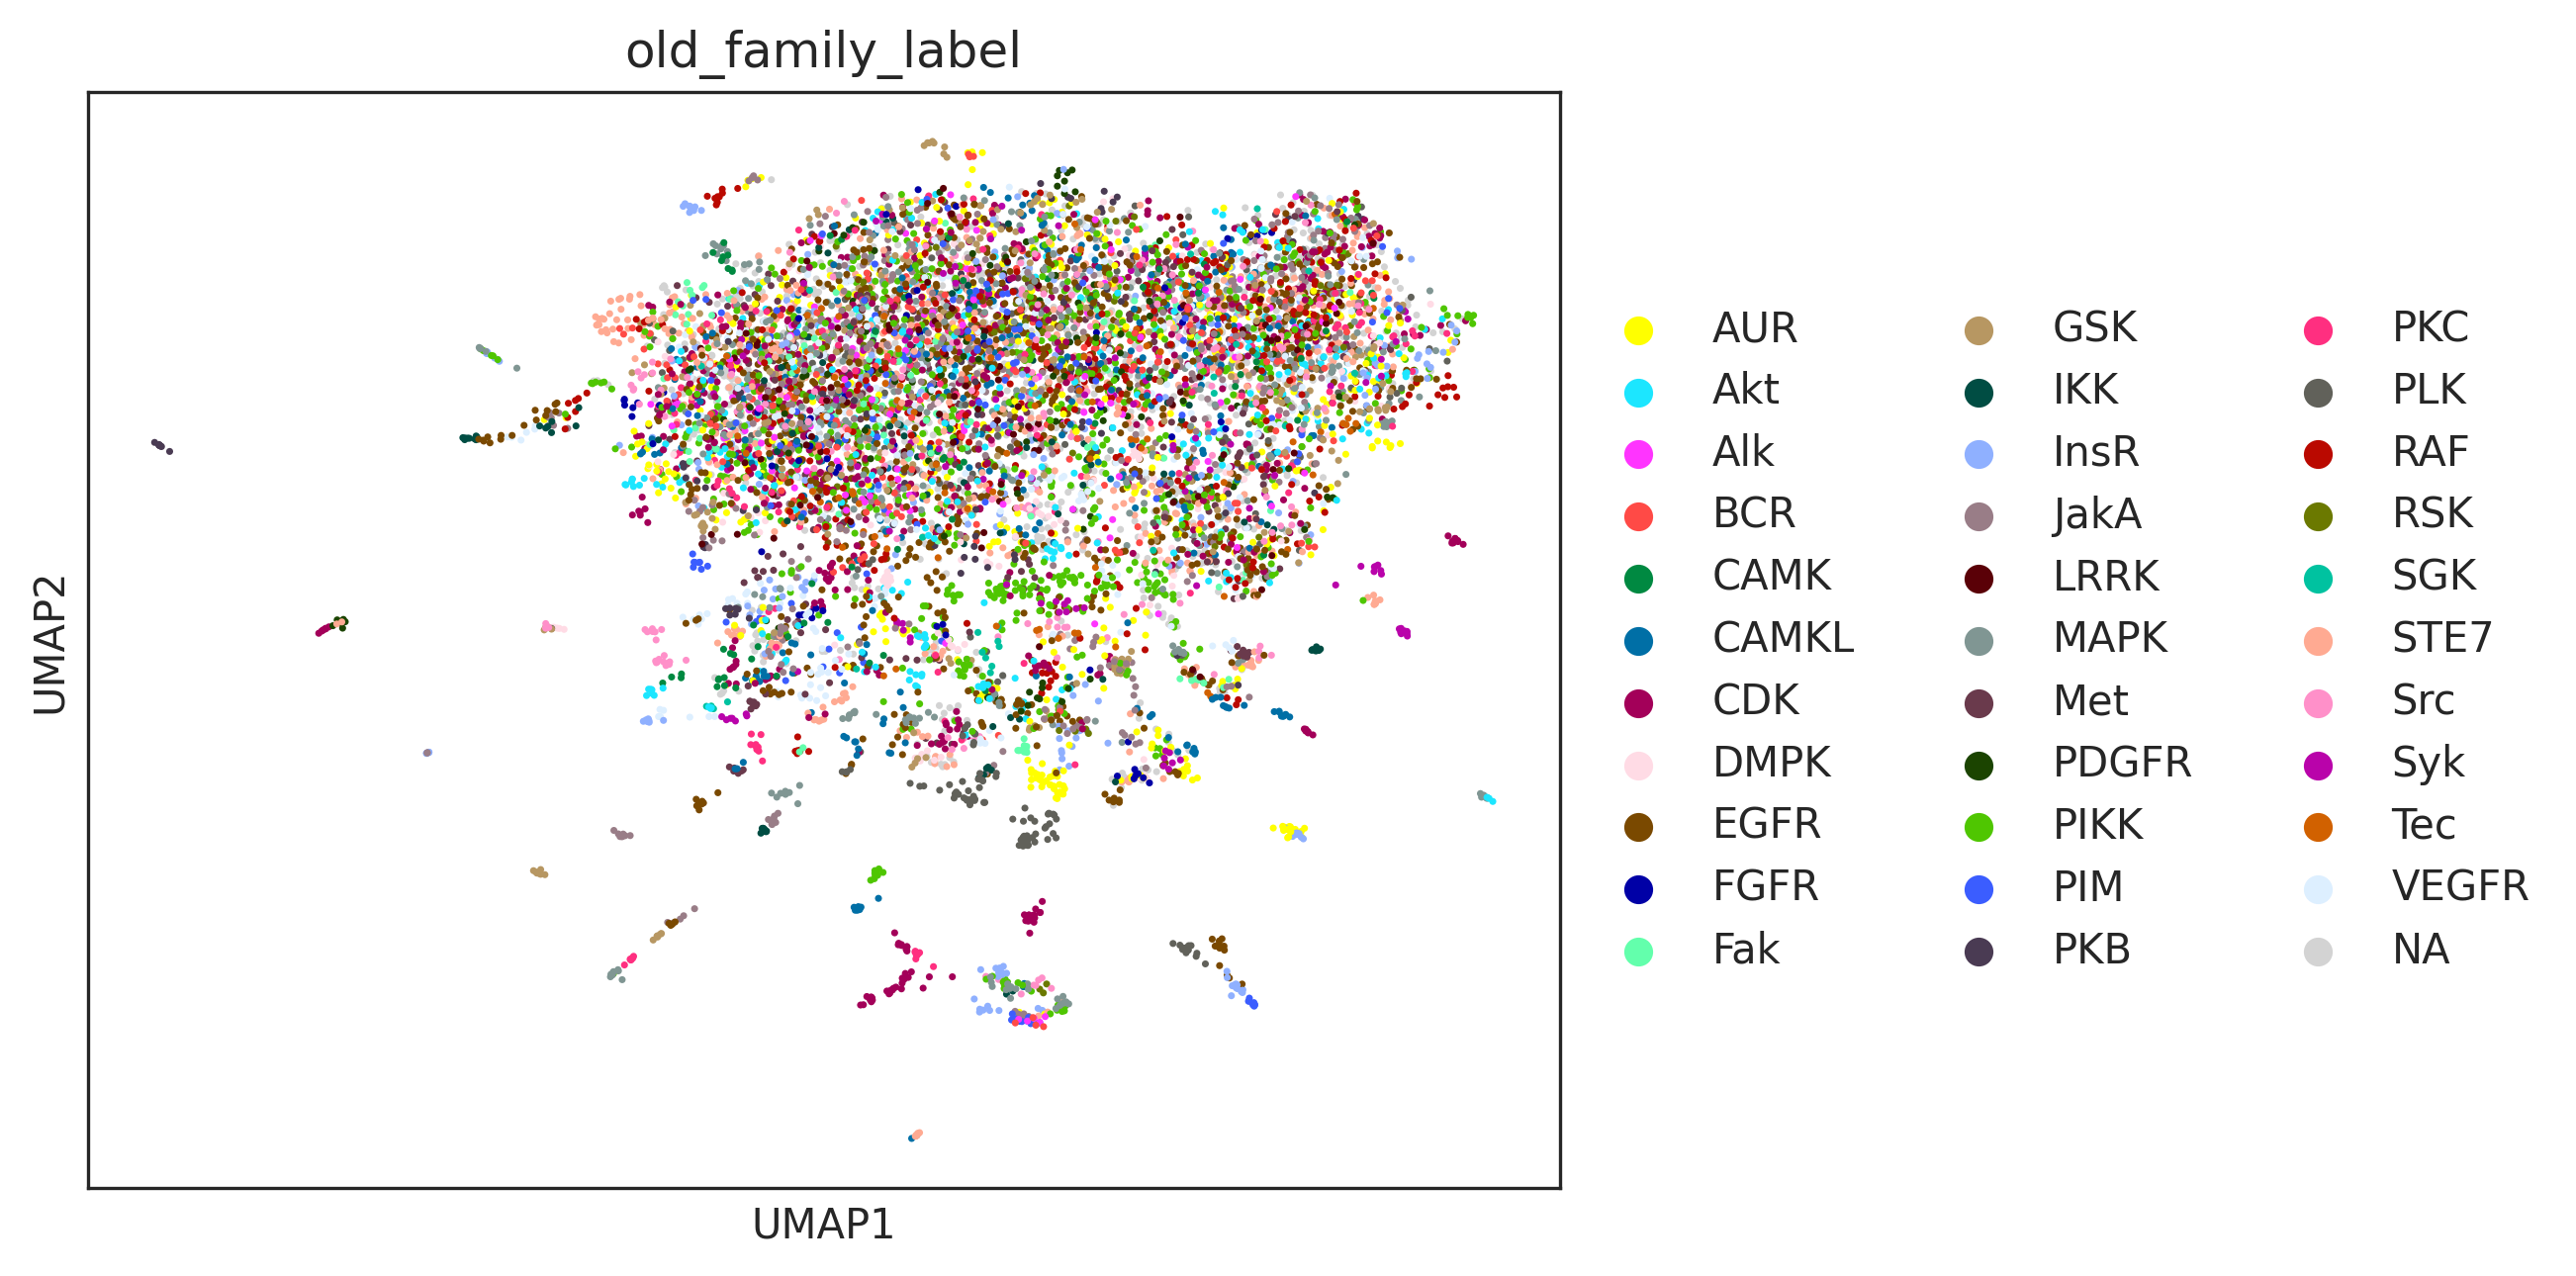

In [20]:
sc.pl.umap(adata,color='old_family_label')


In [21]:
# grits CP 
grits_CP_over1 = '/home/jovyan/share/data/analyses/sofia/kinase378-vt1/CellProfiler/U2OS/U2OS_std_g1_metasof.csv'
df_grits_CP_over1 = pd.read_csv(f'{grits_CP_over1}', sep=';')

In [24]:
comp = df_grits_CP_over1.ReplicateGroup.unique()

In [27]:
adata_1=adata[adata.obs.ReplicateGroup.isin(comp)]


/usr/local/lib/python3.10/dist-packages/scanpy/preprocessing/_pca.py:325: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm["X_pca"] = X_pca


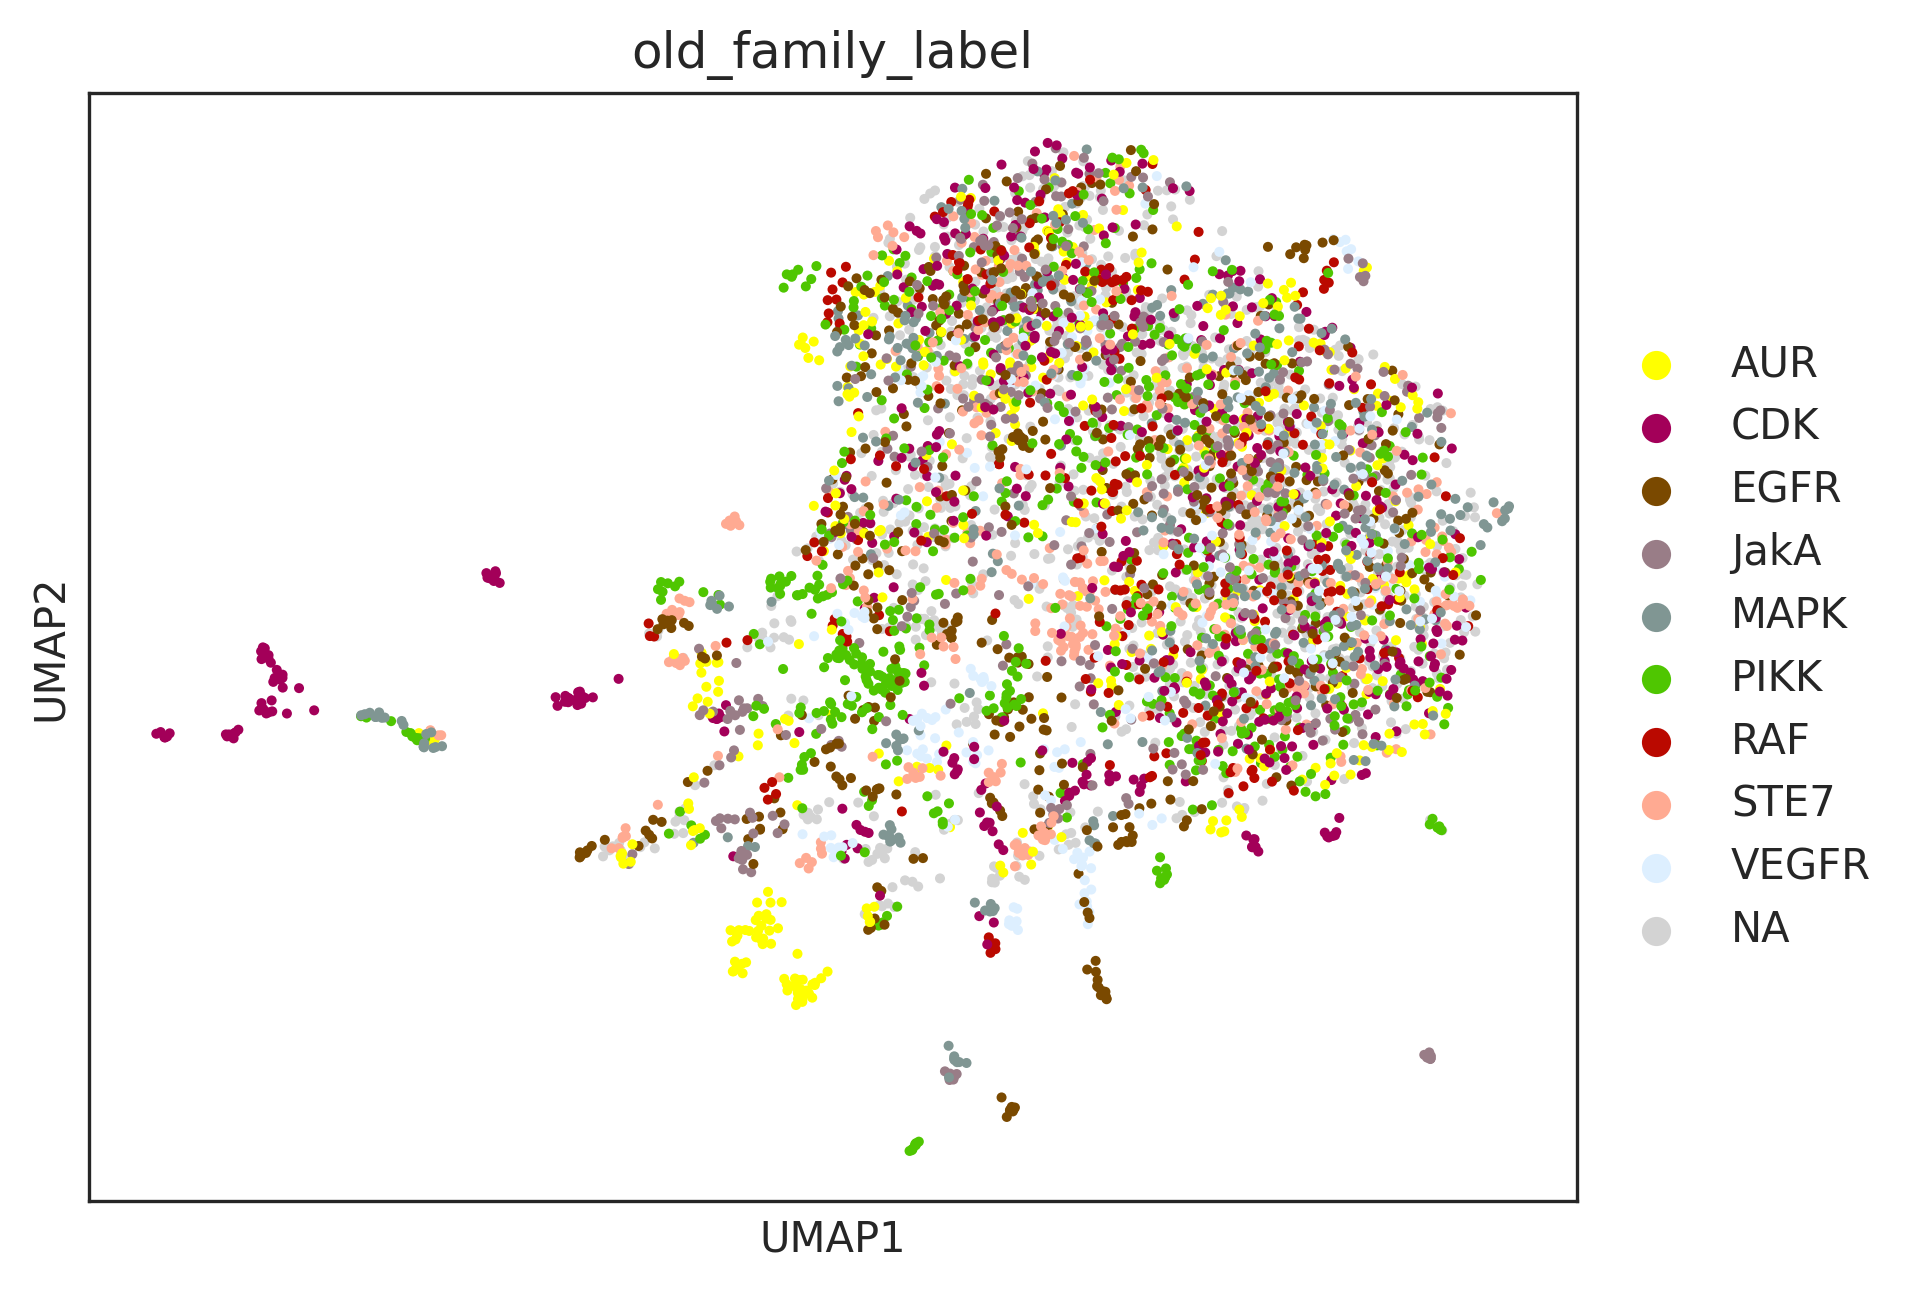

In [28]:
sc.tl.pca(adata_1, svd_solver='arpack')
sc.pp.neighbors(adata_1, n_neighbors=10)
sc.tl.umap(adata_1)
sc.pl.umap(adata_1,color='old_family_label')

In [30]:
barcodes = df_features_STANDARDscaled.Plate.unique()
for barcode in barcodes:
    plate_df = df_features_STANDARDscaled[df_features_STANDARDscaled.Plate == barcode]
    plate_df = plate_df[plate_df.compound_id == '[dmso]'][features_columns]
    display(plate_df.mean())

0     -1.223712e-15
1     -3.552714e-15
2      6.769893e-15
3     -8.190979e-16
4     -2.866843e-15
           ...     
667    4.539579e-16
668   -7.598860e-16
669    9.473903e-16
670   -3.552714e-16
671    1.825700e-16
Length: 672, dtype: float64

0      3.454027e-15
1     -3.227048e-15
2      1.708263e-14
3     -3.534210e-16
4     -1.337202e-15
           ...     
667   -1.060880e-15
668    1.085551e-16
669   -4.934325e-16
670   -9.868649e-18
671   -1.418618e-16
Length: 672, dtype: float64

0     -1.578984e-16
1      1.776357e-16
2      8.832441e-16
3      3.898116e-16
4      1.115157e-15
           ...     
667   -9.177844e-16
668   -2.023073e-15
669   -7.352144e-16
670   -5.921189e-16
671   -3.829036e-15
Length: 672, dtype: float64

0      1.258253e-15
1     -4.687608e-16
2      9.217318e-15
3     -2.565849e-16
4      7.500173e-16
           ...     
667   -2.654667e-15
668   -4.292862e-16
669    4.144833e-16
670    2.368476e-16
671    5.995204e-16
Length: 672, dtype: float64

0     -6.513308e-16
1     -1.554312e-15
2     -4.144833e-15
3      5.427757e-16
4      2.634929e-15
           ...     
667    1.174369e-15
668    5.131698e-16
669   -3.947460e-16
670    6.513308e-16
671   -1.934255e-15
Length: 672, dtype: float64

0     -7.796233e-16
1      8.289665e-16
2     -1.821753e-14
3     -2.190840e-15
4     -2.948259e-15
           ...     
667    1.134895e-16
668   -9.843977e-16
669   -3.858642e-15
670    1.973730e-17
671   -1.218778e-15
Length: 672, dtype: float64